# Building a modified protein that OpenFF can read

Semaglutide is a 31-residue peptide with a lipid linker acylating one
lysine. The OpenFF post-translational-modification workshop simulates
it, starting from a prepared PDB file that someone had to make first.

This notebook makes that file. It starts from the unmodified peptide,
attaches the linker with mBuild, and reads the result back with
openff-pablo using the workshop's own loader call, unchanged.

## The starting structure

An ordinary protonated peptide. Residue 2 is Aib, and residue 20 is the
lysine that will carry the linker — protonated, as it is at neutral pH.

Aib is not one of the twenty standard residues, so its template is
downloaded from the RCSB on first use.

In [1]:
from mbuild.biopolymers import Protein

protein = Protein("semaglutide_apo.pdb", download=True)
print(protein.n_particles, "atoms, net formal charge", protein.net_formal_charge)

lysine = protein.get_residue(20, chain_id="A")
print("residue 2:", protein.get_residue(2, chain_id="A").name)
print(f"LYS 20: charge {lysine.formal_charge:+d}")

470 atoms, net formal charge -1
residue 2: AIB
LYS 20: charge +1


## The linker

The linker is a registered Chemical Component Dictionary component,
`KUT`. Building it from that component rather than from a SMILES string
matters for one reason: its atoms come out with the names the CCD gives
them. A fragment built from SMILES would get invented names, and every
tool downstream would then need to be told what those names mean.

In [2]:
from demo_fragments import fragment_from_ccd

linker = fragment_from_ccd("KUT", link_atom="C33")
print(linker.n_particles, "atoms, formal charge", linker.formal_charge)
print("bonds to the protein through:", linker.link_atoms["1"])

113 atoms, formal charge 0
bonds to the protein through: C33


## Making the bond

Two calls. `deprotonate` takes the proton off the lysine side chain,
because the ammonium ion at neutral pH has no lone pair and does not
acylate; the neutral amine does. `attach` then removes one hydrogen
from each side and forms the bond.

`leaving_atom_names` says which hydrogen goes. The three hydrogens on
that nitrogen are chemically equivalent, so the choice is arbitrary as
chemistry — but the residue library downstream describes the product by
naming the atom that is *absent*, so the file has to agree with it.

In [3]:
protein.deprotonate(20, "NZ", chain_id="A")
record = protein.attach(
    linker,
    resnum=20,
    atom_name="NZ",
    chain_id="A",
    leaving_atom_names="HZ2",
    relax=False,
)

print(f"{record.residue1.name} {record.atom1_name} - "
      f"{record.residue2.name} {record.atom2_name}")
print("hydrogens removed:", record.leaving1 + record.leaving2)
print(protein.n_particles, "atoms, net formal charge", protein.net_formal_charge)

LYS NZ - KUT C33
hydrogens removed: ('HZ2', 'H61')
580 atoms, net formal charge -2


In [4]:
protein.save_pdb("semaglutide_mbuild.pdb", overwrite=True)
print(protein.bond_records()[-1])

{'residue_names': ('LYS', 'KUT'), 'residue_numbers': (20, 32), 'chain_ids': ('A', 'A'), 'icodes': ('', ''), 'atom_names': ('NZ', 'C33'), 'leaving_atoms': (['HZ2'], ['H61']), 'bond_order': 1}


## Reading it back

This is the workshop's loader call, copied unchanged. It declares the
crosslink: which two residues, which two atoms bond, and which atom
leaves each side. Those are the same names `attach` was given.

Nothing else is needed — no hand-written residue definition, no sidecar
file. `KUT` is a CCD component, so pablo already knows it.

In [5]:
from openff.pablo import STD_CCD_CACHE, topology_from_pdb

STD_CCD_CACHE.auto_download = True
library = STD_CCD_CACHE.with_crosslink(
    residues=["LYS", "KUT"],
    linking_atoms=["NZ", "C33"],
    leaving_atoms=[["HZ2"], ["H61"]],
    bond_order=1,
)

topology = topology_from_pdb("semaglutide_mbuild.pdb", residue_library=library)
molecule = topology.molecule(0)
print(topology.n_molecules, "molecule:", molecule.n_atoms, "atoms,",
      molecule.hill_formula + ",", "net charge", molecule.total_charge)

1 molecule: 580 atoms, C187H289N45O59, net charge -2.0 elementary_charge


One molecule, not two. That is the whole claim: the linker came through
as part of the peptide, not as a separate thing sitting next to it.

In [6]:
view = topology.visualize()
view.clear_representations()
view.add_representation("cartoon", color="#990000")
view.add_representation("licorice", selection="[KUT]", color="#FF7733")
view.center(selection="[KUT]")
view

/home/joelaforet/Shirts-Lab-Linux/mbuild_protein_demos/.pixi/envs/default/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


NGLWidget()

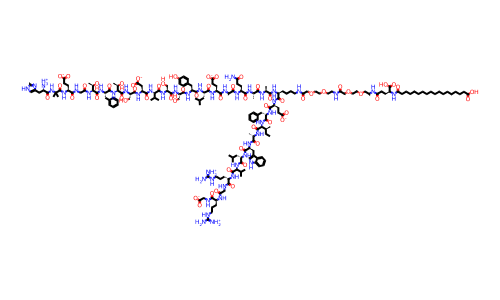

In [7]:
molecule.visualize("rdkit", show_all_hydrogens=False)

## Is it the right molecule?

`semaglutide_reference.pdb` is chain A of the workshop's own
`7KI0_prepared.pdb`. Reading both files through the same loader call
turns the question into a comparison of two OpenFF molecules.

In [8]:
import sys

sys.path.insert(0, "scripts")
from verify_semaglutide import check

check()

  PASS  one molecule, so the linker is bonded    
  PASS  same atom count                          
  PASS  same formula                             
  PASS  same net charge                          
  PASS  same atoms, by element and formal charge 
  PASS  same bonds, by elements and order        
  PASS  isomorphic, setting stereochemistry aside

  580 atoms, 585 bonds, C187H289N45O59, net charge -2.0 elementary_charge

  Stereocentres where the two structures disagree:
    KUT C18: built S, deposited R

  mBuild placed the linker at the geometry its CCD component
  defines. At this centre the deposited coordinates and the CCD
  component disagree, so the two structures differ there.


True

Set stereochemistry aside and the two are the same molecule — not
merely the same formula, but the same graph, atom for atom and bond for
bond.

The one stereocentre that does differ is worth a word, because it is the
kind of thing this pipeline exists to surface. mBuild placed the linker
at the geometry its CCD component defines; at that centre the deposited
coordinates disagree with the component. Neither structure is malformed.
They are two different molecules, and a loader that reads chemistry
rather than coordinates is what tells you so.

## Parameters and a short simulation

From here it is the ordinary OpenFF path, the same as the workshop's.

In [9]:
from openff.toolkit import ForceField

force_field = ForceField("openff_no_water-3.0.0-alpha0.offxml", "opc3.offxml")
interchange = force_field.create_interchange(topology)
print("parameterized", interchange.topology.n_atoms, "atoms")

parameterized 580 atoms


In [10]:
import openmm
from openmm import unit

simulation = interchange.to_openmm_simulation(
    integrator=openmm.LangevinMiddleIntegrator(
        300 * unit.kelvin, 1.0 / unit.picosecond, 2.0 * unit.femtosecond
    ),
)
simulation.minimizeEnergy(maxIterations=200)
simulation.context.setVelocitiesToTemperature(300 * unit.kelvin)
simulation.step(500)
state = simulation.context.getState(getEnergy=True)
print("potential energy:", state.getPotentialEnergy())

potential energy: -706.0149962904977 kJ/mol


## What this needed

Reading the starting file demanded bond orders and formal charges that
are not in a PDB, so the loader matches CCD templates instead of
guessing. Writing the modified file demanded residue numbers, chain
identifiers and CONECT records for exactly the bonds a reader cannot
infer. And making the bond demanded control over which hydrogen leaves,
so that the file agrees with the residue library that reads it.

With those three, the handoff is one loader call with no special
pleading — and the structure that comes out is the one the workshop
simulates.